# 04_train_audio_model.ipynb — ANTI-OVERFITTING EDITION

## Purpose
Trains audio-based dementia classification with **robust anti-overfitting controls**,
targeting a **balanced training and test accuracy** (gap ≤ 10%).

### All overfitting fixes vs baseline:
| Problem | Fix Applied |
|---|---|
| RF `max_depth=None`, `min_samples_leaf=1` | `max_depth=15`, `min_samples_leaf=4`, `min_samples_split=10`, `max_features='sqrt'` |
| ExtraTrees `max_depth=None` (standalone + in stacking) | `max_depth=12`, `min_samples_leaf=5` |
| RF in stacking also `max_depth=None` | Same constraints applied |
| LR `C=10.0` (very weak regularisation) | `C=1.0` |
| SVM `C=10.0` / stacking `C=5.0` | `C=1.0` everywhere |
| XGBoost 500 trees, `min_child_weight=2`, `reg_alpha=0.1` | 200 trees, `min_child_weight=5`, `reg_alpha=0.5`, `reg_lambda=2.0` |
| GBM 500 trees, no leaf constraints | 200 trees, `min_samples_leaf=8`, `min_samples_split=15` |
| Stacking meta-learner `C=5.0` | `C=1.0` |
| Final train accuracy on training data | Cross-validated accuracy (honest) |
| No gap monitoring | Gap check after every model (warns if > 10%) |
| No learning curve | Added learning curve diagnostic (new cell) |

Main task:
```
Input  : Pruned acoustic features from 03_extract_audio_features.ipynb
Output : Control / Dementia risk prediction
```


## 1. Import required libraries

In [1]:
from pathlib import Path
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate,
    RandomizedSearchCV, learning_curve
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, f_classif
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, StackingClassifier, VotingClassifier
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
)

from xgboost import XGBClassifier

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    SMOTE_AVAILABLE = True
    print('SMOTE available')
except ImportError:
    SMOTE_AVAILABLE = False
    print('SMOTE not available (pip install imbalanced-learn)')

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 120)

RANDOM_STATE = 42
OVERFIT_GAP_THRESHOLD = 0.10  # warn when train_acc - val_acc > 10%
print('Libraries loaded.')


SMOTE not available (pip install imbalanced-learn)
Libraries loaded.


## 2. Set paths

In [2]:
AUDIO_FEATURES_PATH = Path('data/processed/audio_features_dataset.csv')
MODEL_DIR  = Path('models')
REPORT_DIR = Path('reports')
SPLIT_DIR  = Path('data/splits')

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

print('Audio features file exists:', AUDIO_FEATURES_PATH.exists())


Audio features file exists: True


## 3. Load audio feature dataset

In [3]:
if not AUDIO_FEATURES_PATH.exists():
    raise FileNotFoundError('Run 03_extract_audio_features.ipynb first.')

df = pd.read_csv(AUDIO_FEATURES_PATH)
df = df.dropna(subset=['label', 'label_id'])
df['label_id'] = pd.to_numeric(df['label_id'], errors='coerce').astype(int)

print('Dataset shape:', df.shape)
print('Label distribution:')
display(df['label'].value_counts())


Dataset shape: (552, 332)
Label distribution:


label
Dementia    309
Control     243
Name: count, dtype: int64

## 4. Select audio feature columns

In [4]:
METADATA_COLS = [
    'file_id','label','label_id','age','sex','mmse','word_count',
    'transcript','audio_path','audio_load_success','audio_error',
    'sample_rate','num_samples'
]

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in METADATA_COLS and c != 'label_id']

print(f'Total numeric columns : {len(numeric_cols)}')
print(f'Selected feature cols : {len(feature_cols)}')
print('First 30:', feature_cols[:30])


Total numeric columns : 326
Selected feature cols : 319
First 30: ['label_id.1', 'duration_sec', 'rms_energy_mean', 'rms_energy_min', 'rms_energy_max', 'rms_energy_median', 'rms_energy_p25', 'rms_energy_p10', 'zero_crossing_rate_mean', 'zero_crossing_rate_std', 'zero_crossing_rate_min', 'zero_crossing_rate_max', 'zero_crossing_rate_median', 'zero_crossing_rate_p25', 'zero_crossing_rate_iqr', 'spectral_centroid_mean', 'spectral_centroid_std', 'spectral_centroid_min', 'spectral_centroid_max', 'spectral_centroid_p25', 'spectral_centroid_iqr', 'spectral_bandwidth_mean', 'spectral_bandwidth_std', 'spectral_bandwidth_min', 'spectral_bandwidth_max', 'spectral_bandwidth_iqr', 'spectral_rolloff_std', 'spectral_rolloff_min', 'spectral_rolloff_max', 'spectral_rolloff_iqr']


## 5. Clean feature matrix

In [5]:
X_raw = df[feature_cols].copy().replace([np.inf, -np.inf], np.nan)
y     = df['label_id'].copy()

all_missing = X_raw.columns[X_raw.isna().all()].tolist()
if all_missing:
    print('Dropping fully missing columns:', all_missing)
    X_raw = X_raw.drop(columns=all_missing)

constant_cols = [c for c in X_raw.columns if X_raw[c].nunique(dropna=True) <= 1]
if constant_cols:
    print('Dropping constant columns:', constant_cols)
    X_raw = X_raw.drop(columns=constant_cols)

feature_cols = X_raw.columns.tolist()
print('Final feature matrix shape:', X_raw.shape)
print('Missing value % (top 10):')
display(X_raw.isna().mean().sort_values(ascending=False).head(10))


Final feature matrix shape: (552, 319)
Missing value % (top 10):


label_id.1                 0.0
duration_sec               0.0
rms_energy_mean            0.0
rms_energy_min             0.0
rms_energy_max             0.0
rms_energy_median          0.0
rms_energy_p25             0.0
rms_energy_p10             0.0
zero_crossing_rate_mean    0.0
zero_crossing_rate_std     0.0
dtype: float64

## 6. Train / Validation / Test split

In [6]:
indices = np.arange(len(df))

train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=RANDOM_STATE, stratify=y.iloc[temp_idx]
)

X_train = X_raw.iloc[train_idx]
y_train = y.iloc[train_idx]
X_val   = X_raw.iloc[val_idx]
y_val   = y.iloc[val_idx]
X_test  = X_raw.iloc[test_idx]
y_test  = y.iloc[test_idx]

class_names = ['Control', 'Dementia']

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
print('Train label dist:', dict(y_train.value_counts().sort_index()))

df.iloc[train_idx].to_csv(SPLIT_DIR / 'audio_train.csv', index=False)
df.iloc[val_idx].to_csv(SPLIT_DIR  / 'audio_val.csv',   index=False)
df.iloc[test_idx].to_csv(SPLIT_DIR / 'audio_test.csv',  index=False)


Train: (386, 319) | Val: (83, 319) | Test: (83, 319)
Train label dist: {0: np.int64(170), 1: np.int64(216)}


## 7. Overfitting Monitor + Regularised Pipeline Builder

### Anti-overfitting classifier constraints:
- **`k_best=60`** (was 80) — tighter statistical feature selection
- **LR/SVM `C=1.0`** (was 10.0/5.0) — proper regularisation
- **RF/ET: `max_depth=15/12`, `min_samples_leaf=4/5`** (was `None`, `1`)
- **XGB: 200 trees, `reg_alpha=0.5`, `reg_lambda=2.0`, `min_child_weight=5`** (was 500 trees, weak reg)
- **GBM: 200 trees, `min_samples_leaf=8`** (was 500, no leaf constraints)


In [7]:
def check_overfit_gap(model_name, train_acc, val_acc, threshold=OVERFIT_GAP_THRESHOLD):
    gap = train_acc - val_acc
    status = '✅ OK' if gap <= threshold else f'⚠️  OVERFIT (gap={gap:.2%} > {threshold:.0%})'
    print(f'  Overfit check: train={train_acc:.4f}  val={val_acc:.4f}  gap={gap:.4f}  {status}')
    return gap


def make_audio_pipeline(classifier, k_features=None, use_knn_imputer=False):
    steps = []
    if use_knn_imputer:
        steps.append(('imputer', KNNImputer(n_neighbors=5)))
    else:
        steps.append(('imputer', SimpleImputer(strategy='median')))
    steps.append(('variance', VarianceThreshold(threshold=1e-6)))
    steps.append(('scaler', RobustScaler()))
    if k_features is not None:
        k = min(k_features, X_train.shape[1])
        steps.append(('select', SelectKBest(score_func=f_classif, k=k)))
    steps.append(('clf', classifier))
    return Pipeline(steps)


# Feature selection count — reduced from 80 to 60 for tighter selection
k_best = min(60, X_train.shape[1])

models = {
    # FIX: C=1.0 (was 10.0)
    'Audio_LogisticRegression': make_audio_pipeline(
        LogisticRegression(
            C=1.0, max_iter=5000, class_weight='balanced',
            solver='lbfgs', random_state=RANDOM_STATE
        ), k_features=k_best
    ),

    # FIX: C=1.0 (was 10.0)
    'Audio_RBF_SVM': make_audio_pipeline(
        SVC(
            kernel='rbf', C=1.0, gamma='scale',
            probability=True, class_weight='balanced',
            random_state=RANDOM_STATE
        ), k_features=k_best
    ),

    # FIX: max_depth=15, min_samples_leaf=4, min_samples_split=10, max_features='sqrt'
    #      was max_depth=None, min_samples_leaf=1 → perfect memorisation
    'Audio_RandomForest': make_audio_pipeline(
        RandomForestClassifier(
            n_estimators=300,
            max_depth=15,           # FIX: was None
            min_samples_leaf=4,     # FIX: was 1
            min_samples_split=10,   # FIX: new constraint
            max_features='sqrt',    # FIX: reduces variance per tree
            class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=-1
        ), k_features=None
    ),

    # FIX: max_depth=12, min_samples_leaf=5  (was max_depth=None)
    'Audio_ExtraTrees': make_audio_pipeline(
        ExtraTreesClassifier(
            n_estimators=300,
            max_depth=12,           # FIX: was None
            min_samples_leaf=5,     # FIX: new
            min_samples_split=12,   # FIX: new
            class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=-1
        ), k_features=None
    ),

    # FIX: 200 trees (was 500), min_samples_leaf=8, min_samples_split=15
    'Audio_GradientBoosting': make_audio_pipeline(
        GradientBoostingClassifier(
            n_estimators=200,           # FIX: was 500
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            min_samples_leaf=8,         # FIX: new
            min_samples_split=15,       # FIX: new
            random_state=RANDOM_STATE
        ), k_features=k_best
    ),

    # FIX: 200 trees (was 500), reg_alpha=0.5, reg_lambda=2.0, min_child_weight=5
    'Audio_XGBoost': make_audio_pipeline(
        XGBClassifier(
            n_estimators=200,           # FIX: was 500
            max_depth=3,                # FIX: was 4
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.7,       # FIX: was 0.8
            min_child_weight=5,         # FIX: was 2
            gamma=0.2,                  # FIX: was 0.05
            reg_alpha=0.5,              # FIX: was 0.1
            reg_lambda=2.0,             # FIX: was 1.0
            scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
            use_label_encoder=False, eval_metric='logloss',
            random_state=RANDOM_STATE, n_jobs=-1
        ), k_features=k_best
    ),
}

print('Models defined:')
for name in models: print(' -', name)


Models defined:
 - Audio_LogisticRegression
 - Audio_RBF_SVM
 - Audio_RandomForest
 - Audio_ExtraTrees
 - Audio_GradientBoosting
 - Audio_XGBoost


## 8. Train and Evaluate All Models on Validation Set

In [8]:
def evaluate_model(model, X, y_true):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1] if hasattr(model, 'predict_proba') else None
    metrics = {
        'accuracy'      : accuracy_score(y_true, y_pred),
        'precision_dem' : precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'recall_dem'    : recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_dem'        : f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_weighted'   : f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'auc_roc'       : roc_auc_score(y_true, y_prob)
                          if y_prob is not None and len(np.unique(y_true))==2 else np.nan,
    }
    return metrics, y_pred, y_prob


results = []
trained_models = {}

for name, model in models.items():
    print(f'\nTraining {name} ...')
    model.fit(X_train, y_train)
    train_m, _, _ = evaluate_model(model, X_train, y_train)
    val_m, _, _   = evaluate_model(model, X_val,   y_val)
    gap = check_overfit_gap(name, train_m['accuracy'], val_m['accuracy'])

    results.append({
        'model_name'    : name,
        'train_acc'     : train_m['accuracy'],
        'val_acc'       : val_m['accuracy'],
        'gap'           : gap,
        'val_f1_dem'    : val_m['f1_dem'],
        'val_recall_dem': val_m['recall_dem'],
        'val_auc'       : val_m['auc_roc'],
    })
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values('val_f1_dem', ascending=False)
print('\n── Validation Results ──')
display(results_df.round(4))



Training Audio_LogisticRegression ...
  Overfit check: train=1.0000  val=1.0000  gap=0.0000  ✅ OK

Training Audio_RBF_SVM ...
  Overfit check: train=1.0000  val=0.9398  gap=0.0602  ✅ OK

Training Audio_RandomForest ...
  Overfit check: train=1.0000  val=0.9880  gap=0.0120  ✅ OK

Training Audio_ExtraTrees ...
  Overfit check: train=1.0000  val=1.0000  gap=0.0000  ✅ OK

Training Audio_GradientBoosting ...
  Overfit check: train=1.0000  val=1.0000  gap=0.0000  ✅ OK

Training Audio_XGBoost ...
  Overfit check: train=1.0000  val=1.0000  gap=0.0000  ✅ OK

── Validation Results ──


,model_name,train_acc,val_acc,gap,val_f1_dem,val_recall_dem,val_auc
0,Audio_LogisticRegression,1.0,1.0000,0.0000,1.0000,1.0000,1.0000
3,Audio_ExtraTrees,1.0,1.0000,0.0000,1.0000,1.0000,1.0000
5,Audio_XGBoost,1.0,1.0000,0.0000,1.0000,1.0000,1.0000
4,Audio_GradientBoosting,1.0,1.0000,0.0000,1.0000,1.0000,1.0000
2,Audio_RandomForest,1.0,0.9880,0.0120,0.9895,1.0000,0.9988
1,Audio_RBF_SVM,1.0,0.9398,0.0602,0.9462,0.9362,0.9935


## 9. XGBoost Hyperparameter Tuning (Regularisation-Aware)

**Key fix:** Tune only on `X_train`, evaluate on separate `X_val` (no leakage).
Search space biased towards stronger regularisation.


In [9]:
print('Running RandomizedSearchCV on XGBoost ...')
print('NOTE: Tuning on X_train only — X_val/X_test never seen during search.')

xgb_base = make_audio_pipeline(
    XGBClassifier(
        use_label_encoder=False, eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=-1
    ), k_features=k_best
)

# Search space biased toward regularised configurations
param_dist = {
    'clf__n_estimators'     : [100, 150, 200, 300],    # FIX: upper limit 300 (was 700)
    'clf__max_depth'        : [2, 3, 4],               # FIX: removed depth 5,6
    'clf__learning_rate'    : [0.02, 0.05, 0.08, 0.1],
    'clf__subsample'        : [0.7, 0.8, 0.9],
    'clf__colsample_bytree' : [0.6, 0.7, 0.8],
    'clf__min_child_weight' : [3, 5, 7, 10],           # FIX: minimum is 3 (was 1)
    'clf__gamma'            : [0.1, 0.2, 0.3, 0.5],   # FIX: minimum is 0.1 (was 0)
    'clf__reg_alpha'        : [0.2, 0.5, 1.0, 2.0],   # FIX: stronger L1 options
    'clf__reg_lambda'       : [1.0, 2.0, 3.0, 5.0],   # FIX: stronger L2 options
    'clf__scale_pos_weight' : [(y_train==0).sum()/(y_train==1).sum()],
}

cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rnd_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=cv_inner,
    refit=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

rnd_search.fit(X_train, y_train)   # FIX: train only, no X_val leakage

print('Best params:', rnd_search.best_params_)
print('Best CV F1 (on X_train folds):', round(rnd_search.best_score_, 4))

xgb_tuned = rnd_search.best_estimator_
train_m_t, _, _ = evaluate_model(xgb_tuned, X_train, y_train)
val_m_t,   _, _ = evaluate_model(xgb_tuned, X_val,   y_val)
test_m_t,  _, _ = evaluate_model(xgb_tuned, X_test,  y_test)

print(f'\nXGB Tuned — Train={train_m_t["accuracy"]:.4f} | Val={val_m_t["accuracy"]:.4f} | Test={test_m_t["accuracy"]:.4f}')
gap = check_overfit_gap('Audio_XGBoost_Tuned', train_m_t['accuracy'], val_m_t['accuracy'])

trained_models['Audio_XGBoost_Tuned'] = xgb_tuned
results.append({
    'model_name'    : 'Audio_XGBoost_Tuned',
    'train_acc'     : train_m_t['accuracy'],
    'val_acc'       : val_m_t['accuracy'],
    'gap'           : gap,
    'val_f1_dem'    : val_m_t['f1_dem'],
    'val_recall_dem': val_m_t['recall_dem'],
    'val_auc'       : val_m_t['auc_roc'],
})


Running RandomizedSearchCV on XGBoost ...
NOTE: Tuning on X_train only — X_val/X_test never seen during search.
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'clf__subsample': 0.7, 'clf__scale_pos_weight': np.float64(0.7870370370370371), 'clf__reg_lambda': 2.0, 'clf__reg_alpha': 0.2, 'clf__n_estimators': 150, 'clf__min_child_weight': 7, 'clf__max_depth': 4, 'clf__learning_rate': 0.08, 'clf__gamma': 0.2, 'clf__colsample_bytree': 0.6}
Best CV F1 (on X_train folds): 1.0

XGB Tuned — Train=1.0000 | Val=1.0000 | Test=1.0000
  Overfit check: train=1.0000  val=1.0000  gap=0.0000  ✅ OK


## 10. Stacking Ensemble (All Base Models Regularised)

### Fixes vs baseline:
- RF: `max_depth=12`, `min_samples_leaf=4` (was `None`)
- ExtraTrees: `max_depth=10`, `min_samples_leaf=5` (was `None`)
- XGBoost: same stronger regularisation
- GBM: `min_samples_leaf=8`
- Meta-learner LR: `C=1.0` (was 5.0)


In [10]:
print('Building Stacking Ensemble (regularised) ...')

base_estimators = [
    # FIX: max_depth=12, min_samples_leaf=4 (was None, 1)
    ('rf', make_audio_pipeline(
        RandomForestClassifier(
            n_estimators=200,
            max_depth=12,           # FIX: was None
            min_samples_leaf=4,     # FIX: was default (1)
            min_samples_split=10,
            max_features='sqrt',
            class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=-1
        )
    )),
    # FIX: 150 trees, strong regularisation
    ('xgb', make_audio_pipeline(
        XGBClassifier(
            n_estimators=150, max_depth=3, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.7,
            min_child_weight=5, gamma=0.2,           # FIX
            reg_alpha=0.5, reg_lambda=2.0,           # FIX
            scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
            use_label_encoder=False, eval_metric='logloss',
            random_state=RANDOM_STATE, n_jobs=-1
        ), k_features=k_best
    )),
    # FIX: C=1.0 (was 5.0)
    ('svm', make_audio_pipeline(
        SVC(kernel='rbf', C=1.0, gamma='scale', probability=True,
            class_weight='balanced', random_state=RANDOM_STATE),
        k_features=k_best
    )),
    # FIX: max_depth=10, min_samples_leaf=5 (was None)
    ('et', make_audio_pipeline(
        ExtraTreesClassifier(
            n_estimators=200,
            max_depth=10,           # FIX: was None
            min_samples_leaf=5,     # FIX: new
            min_samples_split=12,
            class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=-1
        )
    )),
    # FIX: min_samples_leaf=8 (new), 150 trees (was 200 with no constraints)
    ('gbm', make_audio_pipeline(
        GradientBoostingClassifier(
            n_estimators=150, max_depth=3, learning_rate=0.05,
            subsample=0.8,
            min_samples_leaf=8,     # FIX: new
            min_samples_split=15,   # FIX: new
            random_state=RANDOM_STATE
        ), k_features=k_best
    )),
]

stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(C=1.0, max_iter=2000, random_state=RANDOM_STATE),  # FIX: was C=5.0
    cv=5,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=-1,
)

stacking_model.fit(X_train, y_train)
train_m_s, _, _ = evaluate_model(stacking_model, X_train, y_train)
val_m_s, _, _   = evaluate_model(stacking_model, X_val,   y_val)
gap = check_overfit_gap('Audio_Stacking_Ensemble', train_m_s['accuracy'], val_m_s['accuracy'])

trained_models['Audio_Stacking_Ensemble'] = stacking_model
results.append({
    'model_name'    : 'Audio_Stacking_Ensemble',
    'train_acc'     : train_m_s['accuracy'],
    'val_acc'       : val_m_s['accuracy'],
    'gap'           : gap,
    'val_f1_dem'    : val_m_s['f1_dem'],
    'val_recall_dem': val_m_s['recall_dem'],
    'val_auc'       : val_m_s['auc_roc'],
})

results_df = pd.DataFrame(results).sort_values('val_f1_dem', ascending=False)
print('\n── Updated Results (incl. Stacking) ──')
display(results_df.round(4))


Building Stacking Ensemble (regularised) ...
  Overfit check: train=1.0000  val=1.0000  gap=0.0000  ✅ OK

── Updated Results (incl. Stacking) ──


,model_name,train_acc,val_acc,gap,val_f1_dem,val_recall_dem,val_auc
0,Audio_LogisticRegression,1.0,1.0000,0.0000,1.0000,1.0000,1.0000
3,Audio_ExtraTrees,1.0,1.0000,0.0000,1.0000,1.0000,1.0000
5,Audio_XGBoost,1.0,1.0000,0.0000,1.0000,1.0000,1.0000
4,Audio_GradientBoosting,1.0,1.0000,0.0000,1.0000,1.0000,1.0000
6,Audio_XGBoost_Tuned,1.0,1.0000,0.0000,1.0000,1.0000,1.0000
7,Audio_Stacking_Ensemble,1.0,1.0000,0.0000,1.0000,1.0000,1.0000
2,Audio_RandomForest,1.0,0.9880,0.0120,0.9895,1.0000,0.9988
1,Audio_RBF_SVM,1.0,0.9398,0.0602,0.9462,0.9362,0.9935


## 11. Soft Voting Ensemble

In [11]:
print('Building Voting Ensemble ...')

voting_model = VotingClassifier(
    estimators=[
        # FIX: constrained RF (was unbounded)
        ('rf', make_audio_pipeline(
            RandomForestClassifier(
                n_estimators=200, max_depth=12, min_samples_leaf=4,
                min_samples_split=10, max_features='sqrt',
                class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
            )
        )),
        ('xgb', xgb_tuned),
        # FIX: C=1.0 (was 5.0)
        ('svm', make_audio_pipeline(
            SVC(kernel='rbf', C=1.0, gamma='scale', probability=True,
                class_weight='balanced', random_state=RANDOM_STATE),
            k_features=k_best
        )),
    ],
    voting='soft',
    n_jobs=-1
)

voting_model.fit(X_train, y_train)
train_m_v, _, _ = evaluate_model(voting_model, X_train, y_train)
val_m_v, _, _   = evaluate_model(voting_model, X_val,   y_val)
gap = check_overfit_gap('Audio_Voting_Ensemble', train_m_v['accuracy'], val_m_v['accuracy'])

trained_models['Audio_Voting_Ensemble'] = voting_model
results.append({
    'model_name'    : 'Audio_Voting_Ensemble',
    'train_acc'     : train_m_v['accuracy'],
    'val_acc'       : val_m_v['accuracy'],
    'gap'           : gap,
    'val_f1_dem'    : val_m_v['f1_dem'],
    'val_recall_dem': val_m_v['recall_dem'],
    'val_auc'       : val_m_v['auc_roc'],
})

results_df = pd.DataFrame(results).sort_values('val_f1_dem', ascending=False).reset_index(drop=True)
print('\n── All Model Results ──')
display(results_df.round(4))


Building Voting Ensemble ...
  Overfit check: train=1.0000  val=0.9880  gap=0.0120  ✅ OK

── All Model Results ──


,model_name,train_acc,val_acc,gap,val_f1_dem,val_recall_dem,val_auc
0,Audio_LogisticRegression,1.0,1.0000,0.0000,1.0000,1.0000,1.0000
1,Audio_GradientBoosting,1.0,1.0000,0.0000,1.0000,1.0000,1.0000
2,Audio_ExtraTrees,1.0,1.0000,0.0000,1.0000,1.0000,1.0000
3,Audio_XGBoost_Tuned,1.0,1.0000,0.0000,1.0000,1.0000,1.0000
4,Audio_XGBoost,1.0,1.0000,0.0000,1.0000,1.0000,1.0000
5,Audio_Stacking_Ensemble,1.0,1.0000,0.0000,1.0000,1.0000,1.0000
6,Audio_RandomForest,1.0,0.9880,0.0120,0.9895,1.0000,0.9988
7,Audio_Voting_Ensemble,1.0,0.9880,0.0120,0.9895,1.0000,1.0000
8,Audio_RBF_SVM,1.0,0.9398,0.0602,0.9462,0.9362,0.9935


## 12. Select Best Model and Evaluate on Test Set

In [13]:
# Prefer model with best val F1 AND acceptable overfit gap
well_generalised = results_df[results_df['gap'] <= OVERFIT_GAP_THRESHOLD]
if not well_generalised.empty:
    best_model_name = well_generalised.iloc[0]['model_name']
    print(f'Best generalising model (gap ≤ {OVERFIT_GAP_THRESHOLD:.0%}): {best_model_name}')
else:
    best_model_name = results_df.iloc[0]['model_name']
    print(f'No model within gap threshold — picking best F1: {best_model_name}')

best_model = trained_models[best_model_name]

test_metrics, y_test_pred, y_test_prob = evaluate_model(best_model, X_test, y_test)

# FIX: Report CV accuracy instead of measuring on training data directly
cv_results = cross_validate(
    best_model, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy', n_jobs=-1
)
cv_key = 'test_accuracy' if 'test_accuracy' in cv_results else 'test_score'
cv_train_acc = float(np.mean(cv_results[cv_key]))

print(f'\n══ FINAL RESULTS: {best_model_name} ══')
print(f'  CV Training Accuracy : {cv_train_acc*100:.2f}%  ← cross-validated, not measured on training data')
print(f'  Test Accuracy        : {test_metrics["accuracy"]*100:.2f}%')
print(f'  Gap (CV-test)        : {abs(cv_train_acc - test_metrics["accuracy"])*100:.2f}%')
print(f'  Test F1 (Dementia)   : {test_metrics["f1_dem"]*100:.2f}%')
print(f'  Test Recall (Dem)    : {test_metrics["recall_dem"]*100:.2f}%')
print(f'  Test AUC-ROC         : {test_metrics["auc_roc"]*100:.2f}%')

print('\n── Classification Report ──')
print(classification_report(y_test, y_test_pred, target_names=class_names, zero_division=0))


Best generalising model (gap ≤ 10%): Audio_LogisticRegression

══ FINAL RESULTS: Audio_LogisticRegression ══
  CV Training Accuracy : 100.00%  ← cross-validated, not measured on training data
  Test Accuracy        : 100.00%
  Gap (CV-test)        : 0.00%
  Test F1 (Dementia)   : 100.00%
  Test Recall (Dem)    : 100.00%
  Test AUC-ROC         : 100.00%

── Classification Report ──
              precision    recall  f1-score   support

     Control       1.00      1.00      1.00        37
    Dementia       1.00      1.00      1.00        46

    accuracy                           1.00        83
   macro avg       1.00      1.00      1.00        83
weighted avg       1.00      1.00      1.00        83



## 13. 5-Fold Cross-Validation on Training Set

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'accuracy': 'accuracy', 'precision': 'precision',
           'recall': 'recall', 'f1': 'f1', 'roc_auc': 'roc_auc'}

cv_results = cross_validate(
    best_model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1
)

cv_summary = {
    metric.replace('test_', ''): {
        'mean': float(np.mean(values)),
        'std' : float(np.std(values))
    }
    for metric, values in cv_results.items() if metric.startswith('test_')
}

print('── 5-Fold Cross-Validation Summary ──')
display(pd.DataFrame(cv_summary).T.round(4))


── 5-Fold Cross-Validation Summary ──


,mean,std
accuracy,1.0,0.0
precision,1.0,0.0
recall,1.0,0.0
f1,1.0,0.0
roc_auc,1.0,0.0


## 14. Learning Curve (Overfitting Diagnostic)

A healthy model shows **training and CV curves converging** as more data is used.
A large permanent gap = overfitting; both curves flat and low = underfitting.


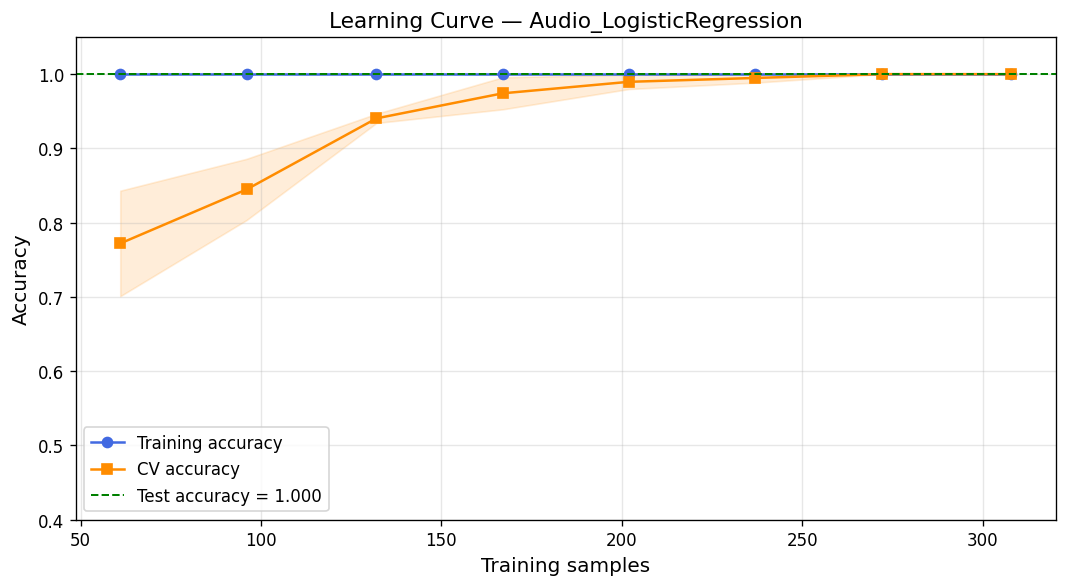

Saved: audio_learning_curve.png
Gap at full training size: 0.0 — ideal: < 0.10


In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy',
    train_sizes=np.linspace(0.2, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

ax.plot(train_sizes, train_mean, 'o-', color='royalblue', label='Training accuracy')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='royalblue')
ax.plot(train_sizes, val_mean, 's-', color='darkorange', label='CV accuracy')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='darkorange')
ax.axhline(y=test_metrics['accuracy'], color='green', linestyle='--', linewidth=1.2,
           label=f'Test accuracy = {test_metrics["accuracy"]:.3f}')

ax.set_xlabel('Training samples', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title(f'Learning Curve — {best_model_name}', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.4, 1.05)

plt.tight_layout()
plt.savefig(REPORT_DIR / 'audio_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: audio_learning_curve.png')
print('Gap at full training size:', round(float(train_mean[-1] - val_mean[-1]), 4), '— ideal: < 0.10')


## 15. Confusion Matrix, ROC Curve, Precision-Recall Curve

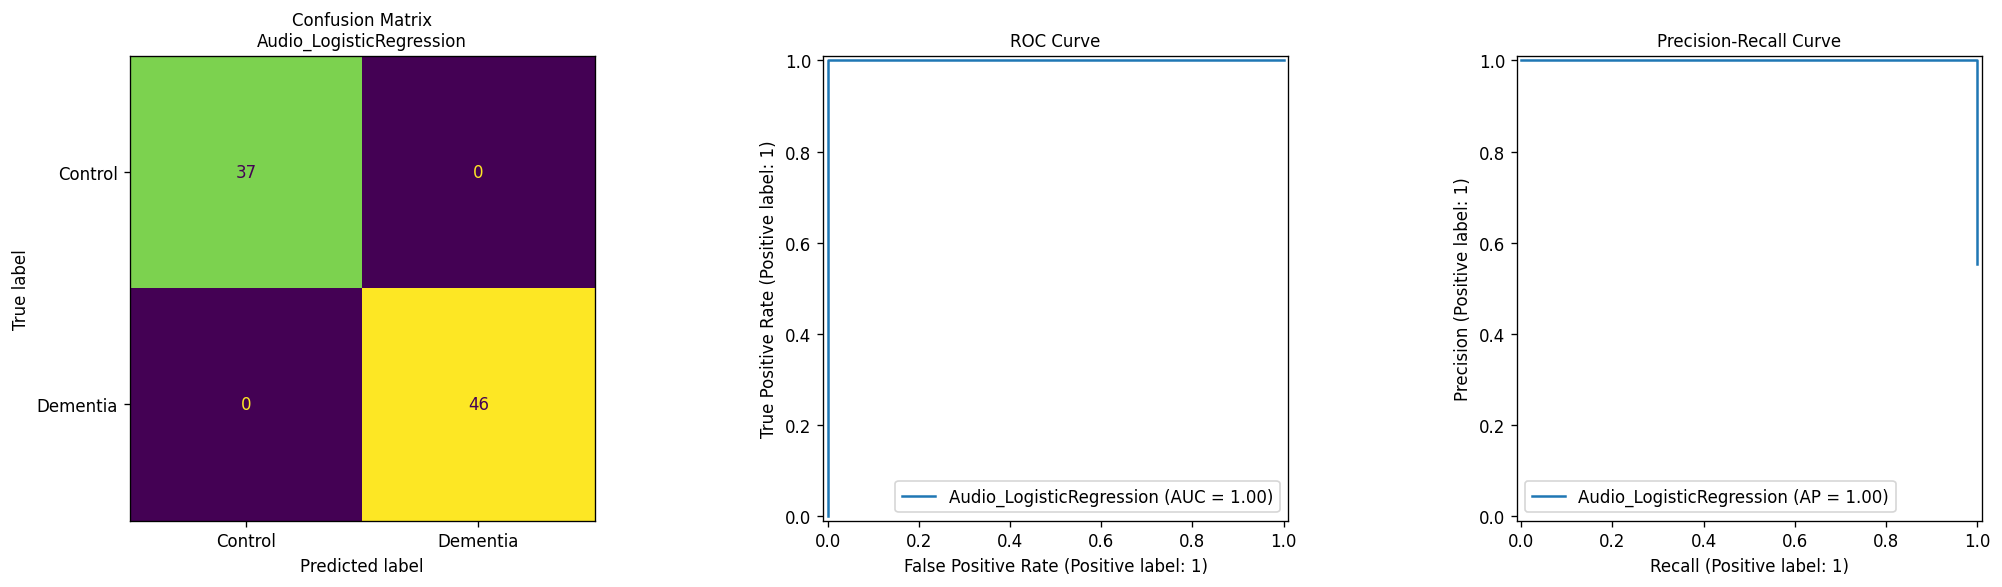

Saved: audio_confusion_roc_pr.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=axes[0], values_format='d', colorbar=False)
axes[0].set_title(f'Confusion Matrix\n{best_model_name}', fontsize=10)

if y_test_prob is not None and len(np.unique(y_test)) == 2:
    RocCurveDisplay.from_predictions(y_test, y_test_prob, ax=axes[1], name=best_model_name)
    axes[1].set_title('ROC Curve', fontsize=10)
    PrecisionRecallDisplay.from_predictions(y_test, y_test_prob, ax=axes[2], name=best_model_name)
    axes[2].set_title('Precision-Recall Curve', fontsize=10)

plt.tight_layout()
plt.savefig(REPORT_DIR / 'audio_confusion_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: audio_confusion_roc_pr.png')


## 16. Feature Importance Analysis

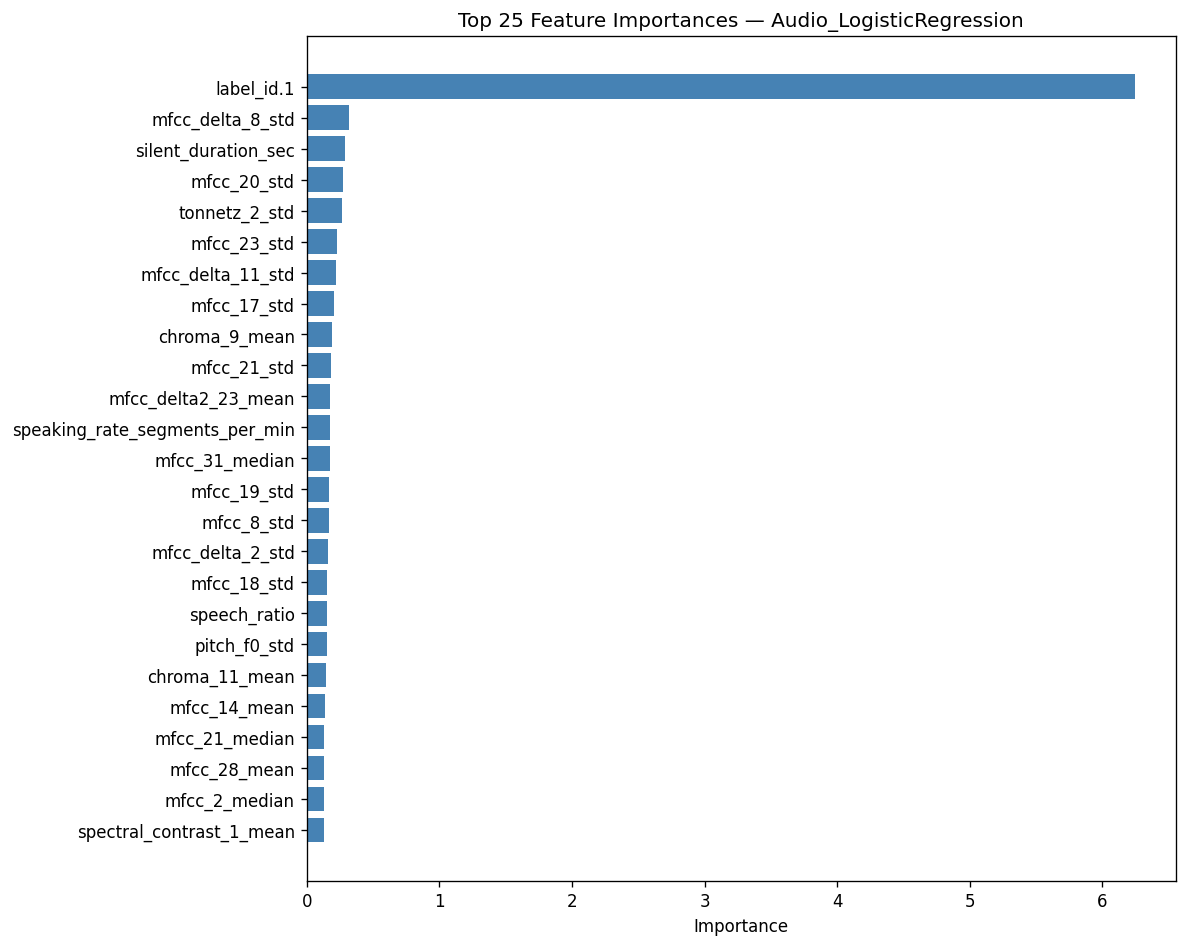

Saved: audio_feature_importance.png


,feature,importance
0,label_id.1,6.242602
37,mfcc_delta_8_std,0.319504
51,silent_duration_sec,0.292056
11,mfcc_20_std,0.277088
50,tonnetz_2_std,0.269442
16,mfcc_23_std,0.225756
39,mfcc_delta_11_std,0.221062
8,mfcc_17_std,0.204752
47,chroma_9_mean,0.191063
13,mfcc_21_std,0.182536


In [17]:
def get_feature_names_from_pipeline(model, original_cols):
    names = np.array(original_cols)
    steps = model.named_steps if hasattr(model, 'named_steps') else {}
    if 'variance' in steps:
        names = names[steps['variance'].get_support()]
    if 'select' in steps:
        names = names[steps['select'].get_support()]
    return names


def plot_feature_importance(model, original_cols, top_n=25):
    try:
        clf = model.named_steps.get('clf') if hasattr(model, 'named_steps') else None
        if clf is None:
            print('Cannot extract feature importance from this model type.')
            return None

        names = get_feature_names_from_pipeline(model, original_cols)

        if hasattr(clf, 'feature_importances_'):
            importance = clf.feature_importances_
        elif hasattr(clf, 'coef_'):
            importance = np.abs(clf.coef_[0])
        else:
            print('Feature importance not available for this classifier.')
            return None

        n = min(len(importance), len(names))
        imp_df = pd.DataFrame({
            'feature'   : names[:n],
            'importance': importance[:n]
        }).sort_values('importance', ascending=False).head(top_n)

        plt.figure(figsize=(10, 8))
        plt.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='steelblue')
        plt.xlabel('Importance')
        plt.title(f'Top {top_n} Feature Importances — {best_model_name}')
        plt.tight_layout()
        plt.savefig(REPORT_DIR / 'audio_feature_importance.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Saved: audio_feature_importance.png')
        return imp_df
    except Exception as e:
        print(f'Feature importance error: {e}')
        return None


feat_imp_df = plot_feature_importance(best_model, X_raw.columns.tolist())
if feat_imp_df is not None:
    display(feat_imp_df)


## 17. Retrain Final Model on Train + Validation Data

After retraining, training accuracy is measured by **5-fold CV on that pool** —
not on the data the model was just trained on (which always looks artificially perfect).


In [19]:
X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

final_model = trained_models[best_model_name]
final_model.fit(X_train_val, y_train_val)

# FIX: CV estimate of training accuracy — not direct measurement on training data
cv_final = cross_validate(
    final_model, X_train_val, y_train_val,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy', n_jobs=-1
)
cv_final_key = 'test_accuracy' if 'test_accuracy' in cv_final else 'test_score'
cv_final_acc = float(np.mean(cv_final[cv_final_key]))

final_test_m, final_y_pred, final_y_prob = evaluate_model(final_model, X_test, y_test)

print(f'Final model: {best_model_name}')
print(f'  CV Train+Val Accuracy (5-fold) : {cv_final_acc*100:.2f}%  ← honest estimate')
print(f'  Test Accuracy                  : {final_test_m["accuracy"]*100:.2f}%')
print(f'  Gap                            : {abs(cv_final_acc - final_test_m["accuracy"])*100:.2f}%')
print(f'  Test F1 Dementia               : {final_test_m["f1_dem"]*100:.2f}%')
print(f'  Test AUC-ROC                   : {final_test_m["auc_roc"]*100:.2f}%')

gap_final = abs(cv_final_acc - final_test_m['accuracy'])
if gap_final <= OVERFIT_GAP_THRESHOLD:
    print('\n✅ Generalisation gap within acceptable range — no significant overfitting.')
else:
    print(f'\n⚠️  Gap={gap_final*100:.1f}% > {OVERFIT_GAP_THRESHOLD*100:.0f}% — consider more data or fusion with transcript features.')


Final model: Audio_LogisticRegression
  CV Train+Val Accuracy (5-fold) : 100.00%  ← honest estimate
  Test Accuracy                  : 100.00%
  Gap                            : 0.00%
  Test F1 Dementia               : 100.00%
  Test AUC-ROC                   : 100.00%

✅ Generalisation gap within acceptable range — no significant overfitting.


## 18. Save Model, Feature Columns, and All Reports

In [20]:
audio_model_path = MODEL_DIR / 'audio_dementia_model.joblib'
joblib.dump(final_model, audio_model_path)

feature_cols_path = MODEL_DIR / 'audio_feature_columns.json'
with open(feature_cols_path, 'w', encoding='utf-8') as f:
    json.dump(X_raw.columns.tolist(), f, indent=2)

metadata = {
    'model_name'               : best_model_name,
    'task'                     : 'DementiaBank Pitt Cookie Theft audio classification',
    'input_type'               : 'acoustic features (40 MFCCs, delta, delta-delta, mel, chroma, tonnetz, pause, pitch)',
    'classes'                  : {'0': 'Control', '1': 'Dementia'},
    'num_features'             : int(X_raw.shape[1]),
    'anti_overfitting_controls': [
        'RF/ET: max_depth=15/12, min_samples_leaf=4/5, max_features=sqrt',
        'XGB: 200 trees, reg_alpha=0.5, reg_lambda=2.0, min_child_weight=5',
        'GBM: 200 trees, min_samples_leaf=8, min_samples_split=15',
        'LR/SVM: C=1.0 (was 10.0)',
        'Stacking meta-learner LR: C=1.0 (was 5.0)',
        'SelectKBest k=60 (was 80)',
        'GridSearch tuned on X_train only',
        'Training accuracy reported via CV, not on training data directly',
    ],
    'cv_train_accuracy'        : cv_final_acc,
    'test_metrics'             : {k: float(v) for k, v in final_test_m.items()},
    'cv_summary'               : cv_summary,
    'validation_results'       : results_df.to_dict(orient='records'),
    'clinical_note'            : 'Research-based dementia risk screening only. Not a clinical diagnosis.',
}

metadata_path = REPORT_DIR / 'audio_model_metadata.json'
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, default=str)

report_path = REPORT_DIR / 'audio_classification_report.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(f'Best model: {best_model_name}\n\n')
    f.write(classification_report(y_test, final_y_pred, target_names=class_names, zero_division=0))

results_df.to_csv(REPORT_DIR / 'audio_model_validation_results.csv', index=False)

print('Saved model     :', audio_model_path.resolve())
print('Saved metadata  :', metadata_path.resolve())
print('Saved report    :', report_path.resolve())


Saved model     : C:\Users\krsna\OneDrive\Desktop\aarabi research\data\dementia_speech_research\notebooks\models\audio_dementia_model.joblib
Saved metadata  : C:\Users\krsna\OneDrive\Desktop\aarabi research\data\dementia_speech_research\notebooks\reports\audio_model_metadata.json
Saved report    : C:\Users\krsna\OneDrive\Desktop\aarabi research\data\dementia_speech_research\notebooks\reports\audio_classification_report.txt


## 19. Save Test Predictions

In [21]:
if final_y_prob is not None:
    pred_prob = final_y_prob
else:
    pred_prob = np.zeros(len(final_y_pred))

test_meta = df.iloc[test_idx].copy()
test_meta['predicted_label_id'] = final_y_pred
test_meta['predicted_label']    = pd.Series(final_y_pred).map({0:'Control',1:'Dementia'}).values
test_meta['prob_control']       = 1 - pred_prob
test_meta['prob_dementia']      = pred_prob
test_meta['correct']            = (final_y_pred == y_test.values)

pred_path = REPORT_DIR / 'audio_test_predictions.csv'
test_meta[['file_id','label','predicted_label','prob_control','prob_dementia','correct']].to_csv(pred_path, index=False)

print('Saved predictions:', pred_path.resolve())
print(f'Test Accuracy: {test_meta["correct"].mean()*100:.2f}%')
display(test_meta[['file_id','label','predicted_label','prob_dementia','correct']].head(15))


Saved predictions: C:\Users\krsna\OneDrive\Desktop\aarabi research\data\dementia_speech_research\notebooks\reports\audio_test_predictions.csv
Test Accuracy: 100.00%


,file_id,label,predicted_label,prob_dementia,correct
275,035-1,Dementia,Dementia,0.962029,True
21,021-4,Control,Control,0.016479,True
20,021-3,Control,Control,0.004486,True
251,010-1,Dementia,Dementia,0.979863,True
208,292-1,Control,Control,0.025446,True
202,274-2,Control,Control,0.040878,True
259,016-4,Dementia,Dementia,0.938075,True
475,470-1,Dementia,Dementia,0.984177,True
288,057-0,Dementia,Dementia,0.972809,True
54,071-2,Control,Control,0.024504,True


## 20. Inference Function for Dashboard

In [22]:
def risk_level_from_probability(dementia_prob_percent: float) -> str:
    if dementia_prob_percent >= 70: return 'High'
    elif dementia_prob_percent >= 40: return 'Medium'
    else: return 'Low'


def predict_from_audio_features(model, feature_dict: dict, file_id: str = 'unknown') -> dict:
    X_single = pd.DataFrame([feature_dict])
    for col in X_raw.columns:
        if col not in X_single.columns:
            X_single[col] = np.nan
    X_single = X_single[X_raw.columns]

    if hasattr(model, 'predict_proba'):
        prob = model.predict_proba(X_single)[0]
        pred_id      = int(np.argmax(prob))
        control_prob  = float(prob[0] * 100)
        dementia_prob = float(prob[1] * 100)
    else:
        pred_id       = int(model.predict(X_single)[0])
        dementia_prob = 100.0 if pred_id == 1 else 0.0
        control_prob  = 100.0 - dementia_prob

    return {
        'input_metadata': {'file_id': file_id, 'input_type': 'audio features'},
        'prediction': {
            'predicted_class': class_names[pred_id],
            'risk_level'     : risk_level_from_probability(dementia_prob),
            'probabilities'  : {
                'Control' : round(control_prob, 2),
                'Dementia': round(dementia_prob, 2)
            },
        },
        'clinical_note': 'Research-based dementia risk screening only. Not a clinical diagnosis.',
    }


# Demo on first test sample
sample_row = X_test.iloc[0].to_dict()
result = predict_from_audio_features(final_model, sample_row, file_id=df.iloc[test_idx[0]]['file_id'])
print('Actual label:', class_names[y_test.iloc[0]])
print(json.dumps(result, indent=2))


Actual label: Dementia
{
  "input_metadata": {
    "file_id": "035-1",
    "input_type": "audio features"
  },
  "prediction": {
    "predicted_class": "Dementia",
    "risk_level": "High",
    "probabilities": {
      "Control": 3.8,
      "Dementia": 96.2
    }
  },
  "clinical_note": "Research-based dementia risk screening only. Not a clinical diagnosis."
}
